# M4.Ex2: Penguins Classification (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex2_pycaret_classification.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **Palmer Penguins Dataset** below:

- [**🚀 Classification**](https://pycaret.gitbook.io/docs/get-started/quickstart#classification)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## Palmer Penguins Dataset

The goal of palmer penguins is to provide a great dataset for data exploration & visualization, as an alternative to iris.

The data contains 344 penguins. There are 3 different species of penguins in this dataset, collected from 3 islands in the Palmer Archipelago, Antarctica.

- Features: `4` numerical, `2` categorical
- Target: `species` (Categorical / 3 classes)
- Size: `344` samples
- Source: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)

### Load the data

In [2]:
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Experiments

1. **First experiment**:
    - X = Flipper Length (numerical) & Bill Length (numerical)
    - y = Species (categorical)
2. **Second experiment**:
    - X = Weights (numerical) & Species (categorical)
    - y = Sex (categroical)
3. **Third experiment**:
    - X = `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
    - y = Sex and Species (multi-label classification)

# First experiment

In [5]:
from pycaret.classification import ClassificationExperiment
Species = penguins[['flipper_length_mm', 'bill_length_mm', 'species']]
Species_clf = ClassificationExperiment()
Species_clf.setup(Species, target='species', session_id=123)

,Description,Value
0,Session id,123
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(344, 3)"
5,Transformed data shape,"(344, 3)"
6,Transformed train set shape,"(240, 3)"
7,Transformed test set shape,"(104, 3)"
8,Numeric features,2
9,Rows with missing values,0.6%


In [6]:
Species_best = Species_clf.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9542,0.9867,0.9542,0.9608,0.9550,0.9287,0.9309,0.1570
xgboost,Extreme Gradient Boosting,0.9542,0.9876,0.9542,0.9607,0.9549,0.9286,0.9310,0.0710
knn,K Neighbors Classifier,0.9500,0.9767,0.9500,0.9544,0.9482,0.9207,0.9237,0.0560
gbc,Gradient Boosting Classifier,0.9458,0.0000,0.9458,0.9550,0.9465,0.9159,0.9194,0.2610
lr,Logistic Regression,0.9417,0.0000,0.9417,0.9475,0.9406,0.9080,0.9113,0.8400
dt,Decision Tree Classifier,0.9417,0.9574,0.9417,0.9482,0.9424,0.9090,0.9115,0.0250
ridge,Ridge Classifier,0.9417,0.0000,0.9417,0.9472,0.9397,0.9071,0.9106,0.0250
lda,Linear Discriminant Analysis,0.9417,0.0000,0.9417,0.9472,0.9397,0.9071,0.9106,0.0420
nb,Naive Bayes,0.9375,0.9879,0.9375,0.9419,0.9366,0.9016,0.9044,0.0260
qda,Quadratic Discriminant Analysis,0.9375,0.0000,0.9375,0.9419,0.9354,0.9010,0.9047,0.0240


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

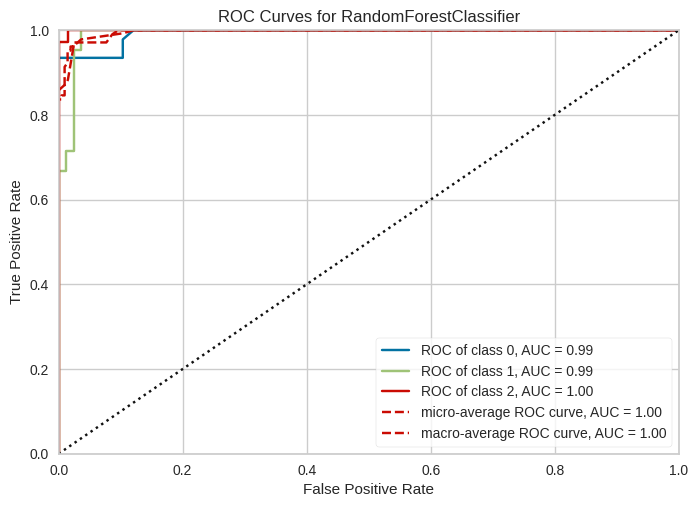

In [10]:
Species_clf.plot_model(Species_best, plot = 'auc')

In [8]:
Species_clf.predict_model(Species_best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9615,0.9952,0.9615,0.9654,0.9617,0.9403,0.9422


,flipper_length_mm,bill_length_mm,species,prediction_label,prediction_score
166,190.0,45.900002,Chinstrap,Chinstrap,0.79
96,190.0,38.099998,Adelie,Adelie,1.00
157,198.0,45.200001,Chinstrap,Chinstrap,0.68
259,208.0,48.700001,Gentoo,Gentoo,0.90
210,202.0,50.200001,Chinstrap,Chinstrap,0.95
...,...,...,...,...,...
278,208.0,43.200001,Gentoo,Gentoo,0.92
32,188.0,39.500000,Adelie,Adelie,0.99
185,203.0,51.000000,Chinstrap,Chinstrap,0.93
149,193.0,37.799999,Adelie,Adelie,1.00


In [9]:
Species_clf.save_model(Species_best, 'my_Species_best_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['flipper_length_mm',
                                              'bill_length_mm'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               miss...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',

# Second experiment

In [13]:
from pycaret.classification import ClassificationExperiment
Sex = penguins[['body_mass_g', 'species','sex']].dropna()
Sex_clf = ClassificationExperiment()
Sex_clf.setup(Sex, target='sex', session_id=123)

,Description,Value
0,Session id,123
1,Target,sex
2,Target type,Binary
3,Target mapping,"Female: 0, Male: 1"
4,Original data shape,"(333, 3)"
5,Transformed data shape,"(333, 5)"
6,Transformed train set shape,"(233, 5)"
7,Transformed test set shape,"(100, 5)"
8,Numeric features,1
9,Categorical features,1


In [14]:
Sex_best = Sex_clf.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8627,0.9139,0.8627,0.8683,0.8617,0.7249,0.7305,0.0980
ridge,Ridge Classifier,0.8591,0.9459,0.8591,0.8623,0.8586,0.7176,0.7209,0.0440
lda,Linear Discriminant Analysis,0.8551,0.9423,0.8551,0.8594,0.8544,0.7097,0.7141,0.0530
lr,Logistic Regression,0.8543,0.9344,0.8543,0.8587,0.8539,0.7083,0.7127,0.9220
et,Extra Trees Classifier,0.8373,0.8657,0.8373,0.8489,0.8354,0.6737,0.6852,0.3430
dt,Decision Tree Classifier,0.8371,0.8546,0.8371,0.8467,0.8352,0.6737,0.6832,0.0800
lightgbm,Light Gradient Boosting Machine,0.8330,0.9314,0.8330,0.8433,0.8306,0.6647,0.6752,0.2390
xgboost,Extreme Gradient Boosting,0.8328,0.9219,0.8328,0.8398,0.8313,0.6647,0.6719,0.0750
rf,Random Forest Classifier,0.8288,0.9043,0.8288,0.8357,0.8273,0.6569,0.6639,0.1650
gbc,Gradient Boosting Classifier,0.8201,0.9197,0.8201,0.8269,0.8184,0.6392,0.6461,0.1140


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

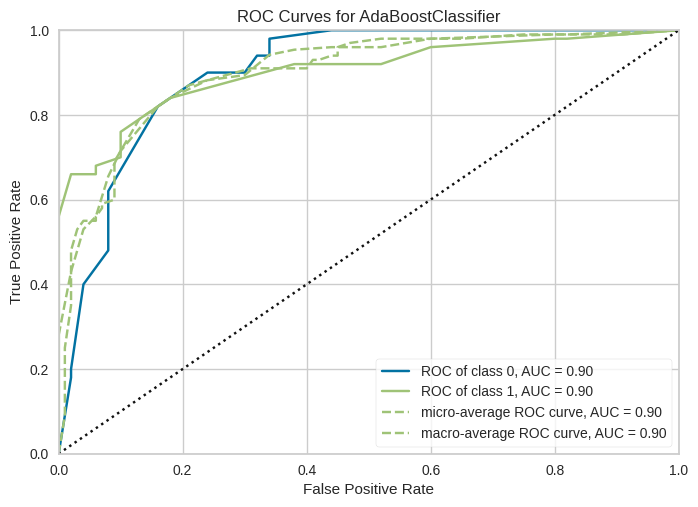

In [16]:
Sex_clf.plot_model(Sex_best, plot = 'auc')

In [17]:
Sex_clf.predict_model(Sex_best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8300,0.9020,0.8300,0.8301,0.8300,0.6600,0.6601


,body_mass_g,species,sex,prediction_label,prediction_score
211,3525.0,Chinstrap,Female,Female,0.5048
219,3775.0,Chinstrap,Female,Male,0.5070
116,2900.0,Adelie,Female,Female,0.6786
242,4400.0,Gentoo,Female,Female,0.5268
99,4100.0,Adelie,Male,Male,0.5199
...,...,...,...,...,...
38,3300.0,Adelie,Female,Female,0.5063
202,3325.0,Chinstrap,Female,Female,0.5190
4,3450.0,Adelie,Female,Female,0.5102
250,5250.0,Gentoo,Male,Male,0.6768


In [18]:
Sex_clf.save_model(Sex_best, 'my_Sex_best_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy...
                  TransformerWrapper(exclude=None, include=['species'],
                                     transformer=OneHotEncoder(cols=['species'],
                

# Third experiment

In [20]:
from pycaret.classification import setup, compare_models

sex_species = penguins[['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'species']].dropna()
sex_species['sex_species'] = sex_species['sex'] + '_' + sex_species['species']

sex_species_clf = setup(
    sex_species,
    target='sex_species',
    session_id=123
)

,Description,Value
0,Session id,123
1,Target,sex_species
2,Target type,Multiclass
3,Target mapping,"Female_Adelie: 0, Female_Chinstrap: 1, Female_Gentoo: 2, Male_Adelie: 3, Male_Chinstrap: 4, Male_Gentoo: 5"
4,Original data shape,"(333, 8)"
5,Transformed data shape,"(333, 12)"
6,Transformed train set shape,"(233, 12)"
7,Transformed test set shape,"(100, 12)"
8,Numeric features,4
9,Categorical features,3


In [22]:
sex_species_best = sex_species_clf.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0750
dt,Decision Tree Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0670
rf,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2660
et,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2270
lightgbm,Light Gradient Boosting Machine,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2930
gbc,Gradient Boosting Classifier,0.9958,0.0000,0.9958,0.9965,0.9957,0.9949,0.9951,0.5050
ridge,Ridge Classifier,0.9957,0.0000,0.9957,0.9971,0.9957,0.9947,0.9949,0.0620
xgboost,Extreme Gradient Boosting,0.9913,1.0000,0.9913,0.9929,0.9912,0.9894,0.9898,0.2880
lr,Logistic Regression,0.9147,0.0000,0.9147,0.9212,0.9118,0.8956,0.8985,0.2030
lda,Linear Discriminant Analysis,0.8924,0.0000,0.8924,0.9138,0.8899,0.8683,0.8736,0.0730


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

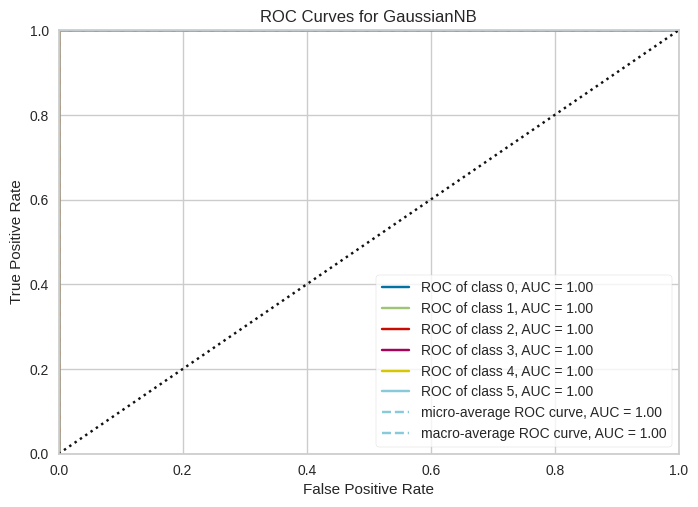

In [28]:
sex_species_clf.plot_model(sex_species_best, plot = 'auc')

In [26]:
sex_species_clf.predict_model(sex_species_best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species,sex_species,prediction_label,prediction_score
97,Dream,40.299999,18.500000,196.0,4350.0,Male,Adelie,Male_Adelie,Male_Adelie,1.0
266,Biscoe,45.500000,13.900000,210.0,4200.0,Female,Gentoo,Female_Gentoo,Female_Gentoo,1.0
137,Dream,40.200001,20.100000,200.0,3975.0,Male,Adelie,Male_Adelie,Male_Adelie,1.0
195,Dream,45.500000,17.000000,196.0,3500.0,Female,Chinstrap,Female_Chinstrap,Female_Chinstrap,1.0
6,Torgersen,38.900002,17.799999,181.0,3625.0,Female,Adelie,Female_Adelie,Female_Adelie,1.0
...,...,...,...,...,...,...,...,...,...,...
304,Biscoe,44.900002,13.800000,212.0,4750.0,Female,Gentoo,Female_Gentoo,Female_Gentoo,1.0
174,Dream,43.200001,16.600000,187.0,2900.0,Female,Chinstrap,Female_Chinstrap,Female_Chinstrap,1.0
171,Dream,49.200001,18.200001,195.0,4400.0,Male,Chinstrap,Male_Chinstrap,Male_Chinstrap,1.0
44,Dream,37.000000,16.900000,185.0,3000.0,Female,Adelie,Female_Adelie,Female_Adelie,1.0


In [27]:
sex_species_clf.save_model(sex_species_best, 'my_sex_species_best_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['bill_length_mm', 'bill_depth_mm',
                                              'flipper_length_mm',
                                              'body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,...
                                                                return_df=True,
                                                                verbose=0))),
                 ('onehot_encoding',
                  TransformerWrapp